# NB18 — Quantum Walks Through a Knowledge Graph

**Quantum Brain Research Laboratory — Alejandro Reynoso**


## Purpose

This notebook implements a continuous-time quantum-walk simulator over the graph
frontier created in NB17. The state

$
|\psi(t)\rangle=e^{-iHt}|\psi(0)\rangle
$

evolves amplitudes across the topology. Measurement yields samples from the final
probability distribution; it does **not** reveal all paths. We compare the quantum walk
with a classical random walk and examine topology, time, marking strength and dephasing.


In [1]:
from pathlib import Path
import importlib.util, subprocess, sys

IN_COLAB = Path("/content").exists()
LAB_ROOT = Path("/content/Quantum_Brain_Lab") if IN_COLAB else Path.cwd() / "Quantum_Brain_Lab"
LAB_ROOT.mkdir(parents=True, exist_ok=True)
DEPS = LAB_ROOT / "_deps"

required = {
    "networkx": "networkx",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}
missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    DEPS.mkdir(parents=True, exist_ok=True)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "--target", str(DEPS), *missing]
    )
    sys.path.insert(0, str(DEPS))

print(f"Laboratory root: {LAB_ROOT}")


Laboratory root: /content/Quantum_Brain_Lab


In [2]:
from __future__ import annotations

import hashlib
import itertools
import json
import math
import random
import time
import zipfile
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

SEED = 271828
RNG = random.Random(SEED)
np.random.seed(SEED)

def stable_hash(value: Any) -> str:
    raw = json.dumps(value, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()

def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()

def cosine_words(a: str, b: str) -> float:
    wa = Counter(x.lower().strip(".,:;!?()") for x in a.split())
    wb = Counter(x.lower().strip(".,:;!?()") for x in b.split())
    keys = set(wa) | set(wb)
    if not keys:
        return 0.0
    va = np.array([wa[k] for k in keys], dtype=float)
    vb = np.array([wb[k] for k in keys], dtype=float)
    den = np.linalg.norm(va) * np.linalg.norm(vb)
    return float(va @ vb / den) if den else 0.0

def build_graph() -> nx.MultiDiGraph:
    """Synthetic governed investment-committee vault."""
    g = nx.MultiDiGraph(graph_version="QB-G0", title="Quantum Brain governed vault")
    nodes = {
        "AlphaBank": ("company", "Diversified bank with floating-rate loans, stable deposits, and legacy systems.", 0.00, 0.92),
        "BetaPayments": ("company", "Cloud-native payments platform with rapid growth, thin margins, and rich transaction data.", 0.20, 0.88),
        "ZetaCloud": ("company", "Enterprise cloud provider with recurring revenue and cyber concentration risk.", 0.05, 0.90),
        "GammaRetail": ("company", "Consumer retailer exposed to imported inventory and discretionary demand.", -0.10, 0.87),
        "DeltaLogistics": ("company", "Regional logistics network with pricing power and fuel exposure.", 0.10, 0.86),
        "EtaInsure": ("company", "Insurer benefiting from reinvestment yields while claims rise with inflation.", 0.00, 0.89),
        "RateShock": ("factor", "Policy rates rise sharply, increasing discount rates and funding costs.", -0.70, 0.96),
        "Regulation": ("factor", "Capital, data, conduct, and model-risk requirements tighten.", -0.40, 0.96),
        "CyberShock": ("factor", "A severe cyber event disrupts critical services and customer trust.", -0.80, 0.98),
        "ConsumerSlowdown": ("factor", "Real disposable income and discretionary demand weaken.", -0.70, 0.95),
        "FXShock": ("factor", "The peso depreciates and imported-input costs rise.", -0.60, 0.94),
        "AcquireBeta": ("decision", "AlphaBank considers acquiring BetaPayments.", 0.00, 0.95),
        "ExpandCredit": ("decision", "AlphaBank considers expanding unsecured consumer credit.", 0.00, 0.95),
        "MigrateCloud": ("decision", "The group considers migrating critical workloads to ZetaCloud.", 0.00, 0.95),
        "HedgeFX": ("decision", "GammaRetail considers increasing its foreign-exchange hedge ratio.", 0.00, 0.95),
        "E01": ("evidence", "Payments data can reduce fraud losses and improve cross-selling at AlphaBank.", 0.85, 0.91),
        "E02": ("evidence", "BetaPayments valuation is highly sensitive to higher discount rates.", -0.90, 0.94),
        "E03": ("evidence", "Legacy-control integration creates a material execution risk.", -0.80, 0.93),
        "E04": ("evidence", "Prior acquisitions performed better when product autonomy was preserved.", 0.70, 0.82),
        "E05": ("evidence", "Tighter data regulation increases the fixed cost of payments integration.", -0.75, 0.92),
        "E06": ("evidence", "A bank-payments data estate improves real-time risk detection.", 0.80, 0.89),
        "E07": ("evidence", "Unsecured credit losses rise nonlinearly in consumer slowdowns.", -0.95, 0.97),
        "E08": ("evidence", "Floating-rate assets initially benefit from higher rates.", 0.60, 0.88),
        "E09": ("evidence", "Deposit repricing can later compress the margin benefit.", -0.55, 0.90),
        "E10": ("evidence", "Independent model validation is required before credit expansion.", -0.65, 0.98),
        "E11": ("evidence", "Cloud migration reduces unit costs and improves analytic flexibility.", 0.75, 0.89),
        "E12": ("evidence", "Single-provider concentration can turn a cyber shock into a systemic outage.", -0.95, 0.97),
        "E13": ("evidence", "Workload segmentation contained a prior service disruption.", 0.65, 0.91),
        "E14": ("evidence", "Multi-cloud resilience reduces concentration but raises coordination cost.", 0.25, 0.85),
        "E15": ("evidence", "Layered FX hedges stabilize gross margin.", 0.75, 0.92),
        "E16": ("evidence", "Over-hedging destroys value if currency weakness reverses.", -0.65, 0.88),
        "E17": ("evidence", "FX collateral calls can create a temporary liquidity shock.", -0.55, 0.90),
        "WeakSignalA": ("signal", "A small merchant cohort is moving from cards to account-to-account payments.", 0.45, 0.67),
        "WeakSignalB": ("signal", "New cyber-insurance exclusions may transfer more outage risk to cloud clients.", -0.50, 0.69),
        "OutcomeAutonomy": ("outcome", "Preserved product autonomy accelerated customer migration in a prior deal.", 0.65, 0.94),
        "OutcomeCredit": ("outcome", "A prior downturn generated losses above the linear stress model.", -0.90, 0.96),
        "OutcomeCloud": ("outcome", "Segmentation reduced recovery time during an earlier outage.", 0.70, 0.95),
        "OutcomeHedge": ("outcome", "The hedge protected margin but triggered a collateral call.", 0.10, 0.95),
    }
    for node_id, (kind, text, polarity, reliability) in nodes.items():
        g.add_node(node_id, kind=kind, text=text, polarity=polarity,
                   reliability=reliability, status="authoritative",
                   source=f"source_{1 + len(node_id) % 9:02d}")
    edges = [
        ("AcquireBeta","AlphaBank","concerns"),("AcquireBeta","BetaPayments","concerns"),
        ("ExpandCredit","AlphaBank","concerns"),("MigrateCloud","ZetaCloud","concerns"),
        ("HedgeFX","GammaRetail","concerns"),("AlphaBank","RateShock","exposed_to"),
        ("AlphaBank","Regulation","exposed_to"),("BetaPayments","RateShock","exposed_to"),
        ("BetaPayments","Regulation","exposed_to"),("BetaPayments","ZetaCloud","depends_on"),
        ("ZetaCloud","CyberShock","exposed_to"),("GammaRetail","FXShock","exposed_to"),
        ("GammaRetail","ConsumerSlowdown","exposed_to"),("GammaRetail","DeltaLogistics","depends_on"),
        ("EtaInsure","RateShock","exposed_to"),("EtaInsure","ConsumerSlowdown","exposed_to"),
        ("RateShock","ConsumerSlowdown","causes"),("CyberShock","Regulation","causes"),
        ("FXShock","ConsumerSlowdown","causes"),
        ("E01","AcquireBeta","supports"),("E02","AcquireBeta","contradicts"),
        ("E03","AcquireBeta","contradicts"),("E04","AcquireBeta","supports"),
        ("E05","AcquireBeta","contradicts"),("E06","AcquireBeta","supports"),
        ("WeakSignalA","BetaPayments","informs"),("WeakSignalA","AcquireBeta","supports"),
        ("E04","OutcomeAutonomy","resulted_in"),("OutcomeAutonomy","AcquireBeta","supports"),
        ("E07","ExpandCredit","contradicts"),("E08","ExpandCredit","supports"),
        ("E09","ExpandCredit","contradicts"),("E10","ExpandCredit","contradicts"),
        ("E07","OutcomeCredit","resulted_in"),("OutcomeCredit","ExpandCredit","contradicts"),
        ("E11","MigrateCloud","supports"),("E12","MigrateCloud","contradicts"),
        ("E13","MigrateCloud","supports"),("E14","MigrateCloud","supports"),
        ("WeakSignalB","CyberShock","informs"),("WeakSignalB","MigrateCloud","contradicts"),
        ("E13","OutcomeCloud","resulted_in"),("OutcomeCloud","MigrateCloud","supports"),
        ("E15","HedgeFX","supports"),("E16","HedgeFX","contradicts"),
        ("E17","HedgeFX","contradicts"),("E15","OutcomeHedge","resulted_in"),
        ("OutcomeHedge","HedgeFX","supports"),
        ("E01","E06","corroborates"),("E03","Regulation","informs"),
        ("E05","Regulation","informs"),("E12","CyberShock","informs"),
        ("E17","FXShock","informs"),("E09","RateShock","informs"),
    ]
    for i, (u, v, rel) in enumerate(edges):
        g.add_edge(u, v, rel=rel, weight=0.65 + 0.35 * ((i % 7) / 6))
    return g

QUERIES = [
    {"id":"Q1","text":"Should AlphaBank acquire BetaPayments under higher rates and tighter regulation?",
     "target":"AcquireBeta","seeds":["RateShock","Regulation"],"risk":"high","expected":"caution"},
    {"id":"Q2","text":"Should AlphaBank expand unsecured credit during a consumer slowdown?",
     "target":"ExpandCredit","seeds":["ConsumerSlowdown","RateShock"],"risk":"high","expected":"caution"},
    {"id":"Q3","text":"How should critical workloads migrate to ZetaCloud under cyber risk?",
     "target":"MigrateCloud","seeds":["CyberShock","Regulation"],"risk":"high","expected":"qualified"},
    {"id":"Q4","text":"How should GammaRetail hedge foreign-exchange depreciation risk?",
     "target":"HedgeFX","seeds":["FXShock","ConsumerSlowdown"],"risk":"medium","expected":"qualified"},
]

def simple_graph(g: nx.MultiDiGraph) -> nx.Graph:
    h = nx.Graph()
    h.add_nodes_from(g.nodes(data=True))
    for u, v, d in g.edges(data=True):
        if h.has_edge(u, v):
            h[u][v]["weight"] += float(d.get("weight", 1.0))
        else:
            h.add_edge(u, v, weight=float(d.get("weight", 1.0)), rels={d.get("rel","related")})
    return h

def enumerate_paths(g: nx.MultiDiGraph, query: dict, cutoff: int = 5, cap: int = 80) -> list[list[str]]:
    h = simple_graph(g)
    starts = list(dict.fromkeys(query["seeds"] + [query["target"]]))
    destinations = [n for n, d in h.nodes(data=True)
                    if d.get("kind") in {"evidence","signal","outcome"}]
    paths = []
    for s in starts:
        for t in destinations:
            if s == t:
                continue
            try:
                for p in nx.all_simple_paths(h, s, t, cutoff=cutoff):
                    if query["target"] in p or any(seed in p for seed in query["seeds"]):
                        paths.append(p)
                        if len(paths) >= cap:
                            break
            except nx.NetworkXNoPath:
                pass
            if len(paths) >= cap:
                break
        if len(paths) >= cap:
            break
    unique = []
    seen = set()
    for p in paths:
        key = tuple(p)
        if key not in seen:
            seen.add(key); unique.append(p)
    return unique

def path_features(g: nx.MultiDiGraph, query: dict, path: list[str]) -> dict:
    attrs = [g.nodes[n] for n in path]
    text = " ".join(a.get("text","") for a in attrs)
    evidence = [a for a in attrs if a.get("kind") in {"evidence","outcome","signal"}]
    polarity = float(np.mean([a.get("polarity",0.0) for a in evidence])) if evidence else 0.0
    reliability = float(np.mean([a.get("reliability",0.5) for a in evidence])) if evidence else 0.5
    relevance = cosine_words(query["text"], text)
    kinds = {a.get("kind") for a in attrs}
    novelty = float(sum(a.get("kind") == "signal" for a in attrs) / max(1, len(path)))
    causal = float(any(g.nodes[n].get("kind") == "factor" for n in path)
                   and any(g.nodes[n].get("kind") in {"decision","outcome"} for n in path))
    contradiction = float(polarity < -0.15)
    support = float(polarity > 0.15)
    bridge = float(len(kinds) / 5.0)
    cost = len(path)
    score = (1.7*relevance + 0.9*reliability + 0.45*novelty + 0.40*causal
             + 0.35*bridge + 0.25*contradiction + 0.20*support - 0.06*cost)
    return {
        "relevance": relevance, "reliability": reliability, "novelty": novelty,
        "causal": causal, "contradiction": contradiction, "support": support,
        "bridge": bridge, "cost": cost, "polarity": polarity, "score": score,
    }

def build_catalog(g: nx.MultiDiGraph, queries: list[dict] = QUERIES) -> pd.DataFrame:
    rows = []
    for q in queries:
        for j, path in enumerate(enumerate_paths(g, q)):
            f = path_features(g, q, path)
            rows.append({"query_id":q["id"],"path_id":f"{q['id']}-P{j:03d}",
                         "path":" -> ".join(path),"nodes":path,**f})
    return pd.DataFrame(rows)

def json_graph(g: nx.MultiDiGraph) -> dict:
    return nx.node_link_data(g, edges="edges")

def load_graph(path: Path) -> nx.MultiDiGraph:
    return nx.node_link_graph(json.loads(path.read_text()), edges="edges",
                              directed=True, multigraph=True)

def ensure_baseline() -> tuple[nx.MultiDiGraph, pd.DataFrame]:
    graph_path = LAB_ROOT / "QB_baseline_graph.json"
    catalog_path = LAB_ROOT / "NB17_path_catalog.csv"
    if graph_path.exists() and catalog_path.exists():
        return load_graph(graph_path), pd.read_csv(catalog_path)
    g = build_graph()
    catalog = build_catalog(g)
    graph_path.write_text(json.dumps(json_graph(g), indent=2))
    catalog.assign(nodes=catalog["nodes"].apply(json.dumps)).to_csv(catalog_path, index=False)
    return g, catalog

def normalized_entropy(p: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    p = p[p > 1e-15]
    return float(-(p*np.log(p)).sum()/np.log(max(2,len(p))))

def jensen_shannon(p: np.ndarray, q: np.ndarray) -> float:
    p = np.asarray(p,dtype=float); q=np.asarray(q,dtype=float)
    p=p/p.sum(); q=q/q.sum(); m=0.5*(p+q)
    def kl(a,b):
        mask=a>1e-15
        return float(np.sum(a[mask]*np.log(a[mask]/np.maximum(b[mask],1e-15))))
    return math.sqrt(max(0.0,0.5*kl(p,m)+0.5*kl(q,m)))

def portfolio_metrics(df: pd.DataFrame) -> dict:
    if df.empty:
        return {"paths":0,"mean_score":0,"contradiction_share":0,"support_share":0,
                "novelty":0,"node_coverage":0,"polarity_balance":0}
    nodes = set()
    for value in df["path"]:
        nodes.update(str(value).split(" -> "))
    return {
        "paths":len(df), "mean_score":float(df["score"].mean()),
        "contradiction_share":float(df["contradiction"].mean()),
        "support_share":float(df["support"].mean()),
        "novelty":float(df["novelty"].mean()), "node_coverage":len(nodes),
        "polarity_balance":float(1-abs(df["polarity"].mean())),
    }


In [3]:
g, catalog = ensure_baseline()
h = simple_graph(g)
nodes=list(h.nodes()); index={n:i for i,n in enumerate(nodes)}
A=nx.to_numpy_array(h,nodelist=nodes,weight="weight",dtype=float)
degree=A.sum(axis=1)
L=np.diag(degree)-A
print(f"Frontier Hamiltonian dimension: {L.shape[0]} x {L.shape[1]}")


Frontier Hamiltonian dimension: 38 x 38


## 1. Quantum and classical propagation


In [4]:
def quantum_walk(query: dict, time_value: float=2.0, marking: float=1.2,
                 dephase: float=0.0) -> np.ndarray:
    H=L.copy()
    marked=list(dict.fromkeys(query["seeds"]+[query["target"]]))
    for n in marked:
        H[index[n],index[n]] -= marking
    eigvals,eigvecs=np.linalg.eigh(H)
    psi0=np.zeros(len(nodes),dtype=complex)
    for n in query["seeds"]:
        psi0[index[n]]=1/math.sqrt(len(query["seeds"]))
    psi=eigvecs @ (np.exp(-1j*time_value*eigvals)*(eigvecs.T.conj()@psi0))
    p=np.abs(psi)**2
    if dephase>0:
        uniform=np.ones(len(nodes))/len(nodes)
        p=(1-dephase)*p+dephase*uniform
    return p/p.sum()

def classical_walk(query: dict, steps: int=12, restart: float=.16) -> np.ndarray:
    P=A/np.maximum(A.sum(axis=1,keepdims=True),1e-12)
    p0=np.zeros(len(nodes))
    for n in query["seeds"]: p0[index[n]]=1/len(query["seeds"])
    p=p0.copy()
    for _ in range(steps):
        p=(1-restart)*(p@P)+restart*p0
    return p/p.sum()


In [5]:
q=QUERIES[0]
times=np.linspace(.2,6.0,36)
records=[]
for t in times:
    pq=quantum_walk(q,t)
    pc=classical_walk(q,steps=max(1,int(2*t)))
    target_mass=pq[index[q["target"]]]
    evidence_mass=sum(pq[index[n]] for n,d in h.nodes(data=True)
                      if d.get("kind") in {"evidence","signal","outcome"})
    records.append({"time":t,"target_mass":target_mass,"evidence_mass":evidence_mass,
                    "entropy":normalized_entropy(pq),"js_from_classical":jensen_shannon(pq,pc)})
evolution=pd.DataFrame(records)
display(evolution.sort_values("evidence_mass",ascending=False).head())


,time,target_mass,evidence_mass,entropy,js_from_classical
20,3.514286,0.000968,0.448201,0.868444,0.346597
21,3.680000,0.015997,0.441768,0.886840,0.323226
27,4.674286,0.021008,0.430686,0.836853,0.326655
26,4.508571,0.012062,0.421002,0.843236,0.334425
28,4.840000,0.015856,0.416253,0.837806,0.318200


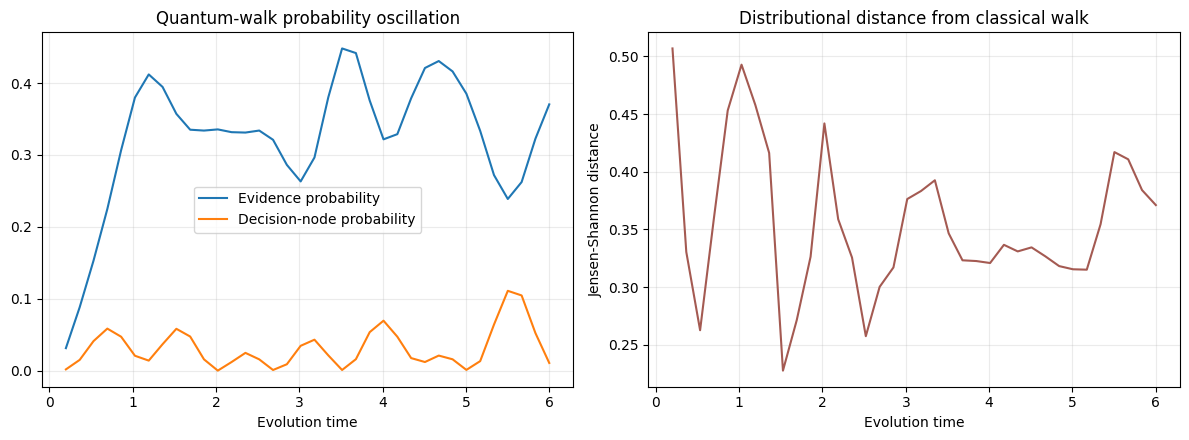

In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].plot(evolution.time,evolution.evidence_mass,label="Evidence probability")
axes[0].plot(evolution.time,evolution.target_mass,label="Decision-node probability")
axes[0].set_title("Quantum-walk probability oscillation"); axes[0].set_xlabel("Evolution time")
axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(evolution.time,evolution.js_from_classical,color="#a45a52")
axes[1].set_title("Distributional distance from classical walk")
axes[1].set_xlabel("Evolution time"); axes[1].set_ylabel("Jensen-Shannon distance")
axes[1].grid(alpha=.25)
plt.tight_layout(); plt.savefig(LAB_ROOT/"NB18_quantum_walk_dynamics.png",dpi=180)
plt.show()


## 2. Measured node portfolios and topology sensitivity


In [7]:
def measured_nodes(prob: np.ndarray, shots: int=4096, keep: int=10) -> pd.DataFrame:
    counts=np.random.multinomial(shots,prob)
    frame=pd.DataFrame({"node":nodes,"probability":prob,"counts":counts})
    frame["kind"]=frame["node"].map(lambda n:g.nodes[n].get("kind"))
    frame["polarity"]=frame["node"].map(lambda n:g.nodes[n].get("polarity",0))
    return frame.nlargest(keep,"counts")

rows=[]; portfolios={}
for q in QUERIES:
    # Choose the time that maximizes evidence mass, using a transparent grid.
    candidates=[]
    for t in times:
        p=quantum_walk(q,float(t))
        evidence=sum(p[index[n]] for n,d in h.nodes(data=True)
                     if d.get("kind") in {"evidence","signal","outcome"})
        candidates.append((evidence,float(t),p))
    _,best_t,pq=max(candidates,key=lambda x:x[0])
    pc=classical_walk(q)
    topq=measured_nodes(pq)
    topc=measured_nodes(pc)
    portfolios[q["id"]]=topq.to_dict("records")
    rows.append({"query_id":q["id"],"best_time":best_t,
                 "quantum_entropy":normalized_entropy(pq),
                 "classical_entropy":normalized_entropy(pc),
                 "js_distance":jensen_shannon(pq,pc),
                 "quantum_evidence_nodes":int((topq.kind.isin(["evidence","signal","outcome"])).sum()),
                 "classical_evidence_nodes":int((topc.kind.isin(["evidence","signal","outcome"])).sum()),
                 "quantum_weak_signals":int((topq.kind=="signal").sum()),
                 "classical_weak_signals":int((topc.kind=="signal").sum())})
walk_comparison=pd.DataFrame(rows)
walk_comparison.to_csv(LAB_ROOT/"NB18_walk_comparison.csv",index=False)
(LAB_ROOT/"NB18_measured_portfolios.json").write_text(json.dumps(portfolios,indent=2))
display(walk_comparison.round(3))


,query_id,best_time,quantum_entropy,classical_entropy,js_distance,quantum_evidence_nodes,classical_evidence_nodes,quantum_weak_signals,classical_weak_signals
0,Q1,3.514,0.868,0.851,0.369,5,1,1,0
1,Q2,6.000,0.828,0.802,0.393,4,0,0,0
2,Q3,1.526,0.818,0.801,0.350,7,3,2,1
3,Q4,5.006,0.674,0.716,0.399,4,3,0,0


## 3. Noise and dephasing stress test


In [8]:
noise_rows=[]
q=QUERIES[2]
base=quantum_walk(q,2.4,dephase=0)
for noise in np.linspace(0,.8,9):
    p=quantum_walk(q,2.4,dephase=float(noise))
    noise_rows.append({"dephasing":noise,"entropy":normalized_entropy(p),
                       "distance_from_ideal":jensen_shannon(base,p),
                       "decision_probability":p[index[q["target"]]]})
noise_df=pd.DataFrame(noise_rows)
noise_df.to_csv(LAB_ROOT/"NB18_noise_stress.csv",index=False)
display(noise_df.round(3))


,dephasing,entropy,distance_from_ideal,decision_probability
0,0.0,0.705,0.000,0.049
1,0.1,0.762,0.085,0.047
2,0.2,0.809,0.139,0.044
3,0.3,0.850,0.185,0.042
4,0.4,0.885,0.227,0.040
5,0.5,0.916,0.268,0.038
6,0.6,0.943,0.307,0.035
7,0.7,0.965,0.347,0.033
8,0.8,0.983,0.389,0.031


In [ ]:
records=[]
for q in QUERIES:
    records.append({
        "object_type":"quantum_navigation_record","query_id":q["id"],
        "graph_version":g.graph.get("graph_version"),"algorithm":"continuous_time_quantum_walk",
        "backend":"numpy_statevector_simulator","hamiltonian":"marked_weighted_graph_laplacian",
        "dimension":len(nodes),"shots":4096,"noise_model":"dephasing_mixture_sweep",
        "graph_hash":stable_hash(json_graph(g)),"created_utc":utc_now(),
        "claim_status":"simulation_only_no_quantum_advantage_claim"
    })
with (LAB_ROOT/"NB18_quantum_navigation_records.jsonl").open("w") as f:
    for record in records: f.write(json.dumps(record)+"\n")
print("Wrote auditable quantum-walk records.")


## Interpretation

A quantum walk produces a topology-sensitive distribution that can differ substantially
from a classical diffusion process. That difference is an experimental object, not yet
evidence of useful quantum advantage. The next notebook asks a different question:
given many admissible paths, can a hybrid quantum-classical optimizer assemble a better
*portfolio* of evidence under a fixed context budget?
